# Benchmark Functions — Superfície 3D e Curvas de Nível

In [13]:
from benchmark import (
    rosenbrock, sphere, sum_squares, dixon_price, zakharov,
    ackley, rastrigin, griewank, schwefel, levy,
)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d  # noqa: F401  (ativa projeção 3d)
from matplotlib.colors import LogNorm

In [14]:
import os

def plot_function(
    func,
    x_range,
    y_range,
    levels: int = 50,
    title: str = "Function",
    func_type: str = "Unimodal",
    clip_percentile: float | None = None,
    use_log: bool = False,
    grid_size: int = 300,
    view_elev: float = 25,
    view_azim: float = 45,
    optimal_point: tuple | None = None,
    cmap: str = "viridis",
):
    """
    Plota superfície 3D e mapa de curvas de nível para uma função de benchmark.

    Parâmetros
    ----------
    clip_percentile : float, opcional
        Limita os valores acima do percentil informado antes de plotar.
        Útil para funções com picos extremos nas bordas (ex.: Rosenbrock).
    use_log        : bool
        Aplica log1p(Z) para comprimir a escala vertical.
    optimal_point  : (x*, y*) ou None
        Marca o ótimo global no mapa de contorno.
    """
    x = np.linspace(*x_range, grid_size)
    y = np.linspace(*y_range, grid_size)
    X, Y = np.meshgrid(x, y)
    XY   = np.column_stack([X.ravel(), Y.ravel()])
    Z    = func(XY).reshape(X.shape)

    if clip_percentile is not None:
        Z = np.clip(Z, None, np.percentile(Z, clip_percentile))

    if use_log:
        Z = np.log1p(Z - Z.min())   # desloca para garantir Z>=0 antes do log

    badge_color = "#185FA5" if func_type == "Unimodal" else "#993C1D"
    z_label     = "log(1 + f)" if use_log else "f(x₁, x₂)"

    fig = plt.figure(figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold", x=0.5, y=1.01)

    # ── Superfície 3D ──────────────────────────────────────────────────────
    ax3d = fig.add_subplot(121, projection="3d")
    ax3d.set_title("Superfície 3D", fontsize=11)
    ax3d.set_xlabel("x₁", labelpad=4)
    ax3d.set_ylabel("x₂", labelpad=4)
    ax3d.set_zlabel(z_label, labelpad=6)
    ax3d.view_init(elev=view_elev, azim=view_azim)

    surf = ax3d.plot_surface(X, Y, Z, cmap=cmap, edgecolor="none", alpha=0.92,
                              rcount=120, ccount=120)

    # Projeção das curvas no plano inferior
    zfloor = Z.min() - 0.05 * (Z.max() - Z.min())
    ax3d.contourf(X, Y, Z, zdir="z", offset=zfloor,
                  levels=20, cmap=cmap, alpha=0.45)
    ax3d.set_zlim(zfloor, Z.max())

    plt.colorbar(surf, ax=ax3d, shrink=0.45, pad=0.08)

    # ── Curvas de nível ────────────────────────────────────────────────────
    ax2d = fig.add_subplot(122)
    ax2d.set_title("Curvas de nível", fontsize=11)
    ax2d.set_xlabel("x₁")
    ax2d.set_ylabel("x₂")
    ax2d.set_aspect("equal")

    cf = ax2d.contourf(X, Y, Z, levels=levels, cmap=cmap)
    cl = ax2d.contour(X, Y, Z, levels=12, colors="black", alpha=0.25, linewidths=0.5)
    ax2d.clabel(cl, inline=True, fontsize=7, fmt="%.1f")
    plt.colorbar(cf, ax=ax2d)

    # Ótimo global
    if optimal_point is not None:
        ox, oy = optimal_point
        ax2d.plot(ox, oy, marker="*", markersize=12, color="white",
                  markeredgecolor="black", markeredgewidth=0.8,
                  zorder=5, label=f"ótimo global ({ox}, {oy:.3f})")
        ax2d.legend(fontsize=8, loc="upper right",
                    framealpha=0.7, edgecolor="gray")

    # Badge tipo
    ax2d.text(0.02, 0.97, func_type.upper(),
              transform=ax2d.transAxes, ha="left", va="top",
              fontsize=8, fontweight="bold", color=badge_color,
              bbox=dict(boxstyle="round,pad=0.3", fc="white",
                        ec=badge_color, lw=0.8, alpha=0.85))

    plt.tight_layout()

    os.makedirs("imagens", exist_ok=True)

    plt.tight_layout()

    nome = (
        title.lower()
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
    )

    plt.savefig(
        os.path.join("imagens", f"{nome}.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

## Funções Unimodais

Apresentam **um único ótimo global** e nenhum ótimo local. Testam principalmente velocidade de convergência e precisão.

### F1 · Sphere
$$f(\mathbf{x}) = \sum_{i=1}^{D} x_i^2 \qquad x_i \in [-100, 100], \quad f^* = 0$$
Função de referência: separável, convexa, perfeitamente simétrica.

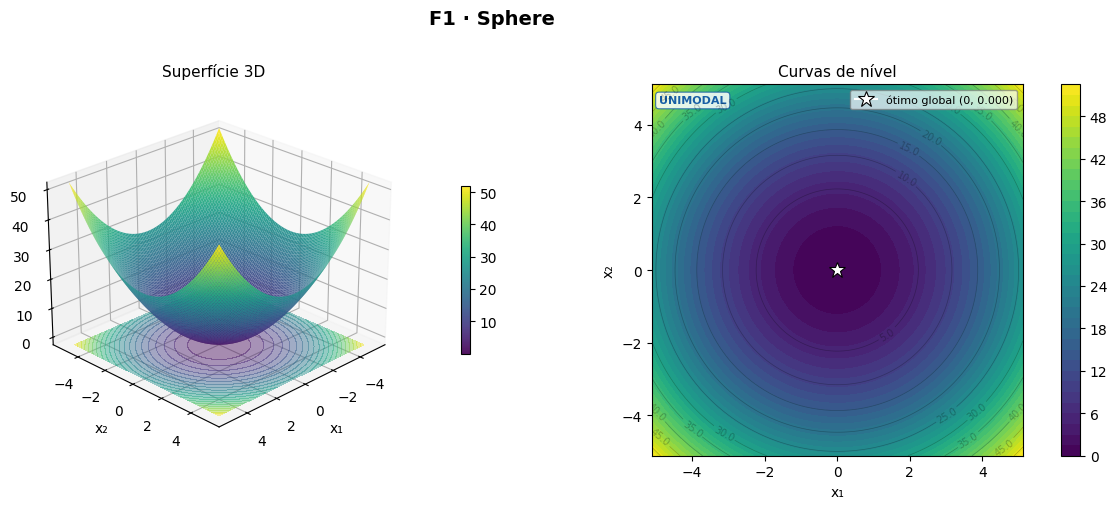

In [15]:
plot_function(sphere, (-5.12, 5.12), (-5.12, 5.12),
              title="F1 · Sphere", func_type="Unimodal",
              optimal_point=(0, 0))

### F2 · Rosenbrock
$$f(\mathbf{x}) = \sum_{i=1}^{D-1}\left[100(x_{i+1}-x_i^2)^2 + (x_i-1)^2\right] \qquad x_i \in [-5, 10], \quad f^* = 0$$

**Observação sobre a visualização:** o domínio de *busca* é $[-5, 10]$, mas nesse intervalo
os valores nas bordas chegam a $\approx 10^6$, tornando o vale curvo completamente invisível na escala.
O domínio de *visualização* adotado — $[-2,\,2]\times[-1,\,3]$ — é o padrão na literatura
(ex.: Hansen & Ostermeier 2001) e preserva toda a estrutura relevante: o vale parabólico
estreito que passa por $(1, 1)$.

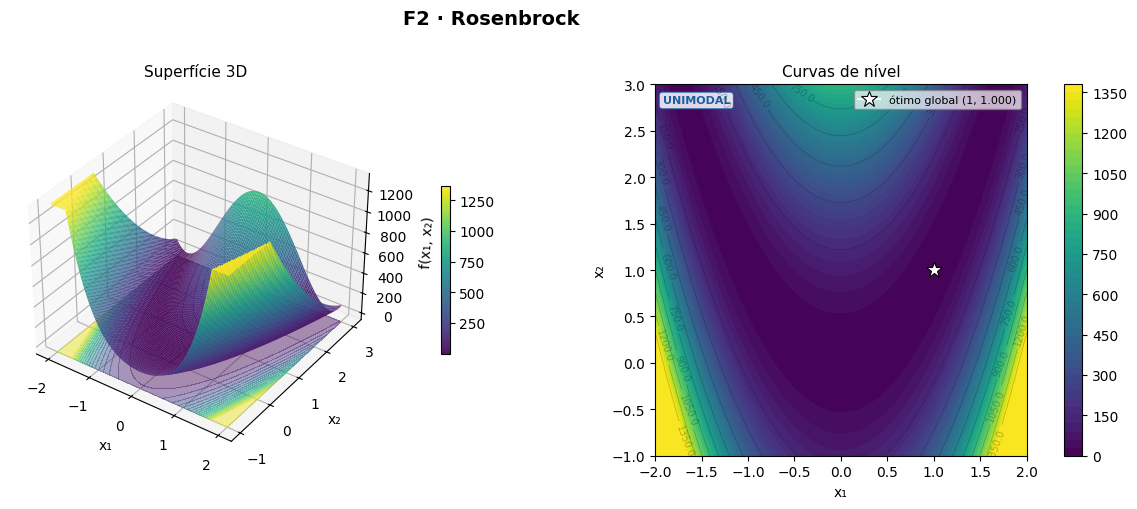

In [16]:
plot_function(
    rosenbrock,
    x_range=(-2, 2), y_range=(-1, 3),   # domínio de VISUALIZAÇÃO (padrão literatura)
    clip_percentile=97,                  # remove picos das bordas sem distorcer o vale
    title="F2 · Rosenbrock", func_type="Unimodal",
    view_elev=35, view_azim=-55,
    optimal_point=(1, 1),
)

### F3 · Sum Squares
$$f(\mathbf{x}) = \sum_{i=1}^{D} i\, x_i^2 \qquad x_i \in [-10, 10], \quad f^* = 0$$
Variante ponderada da Sphere: variáveis com índice maior têm maior influência.

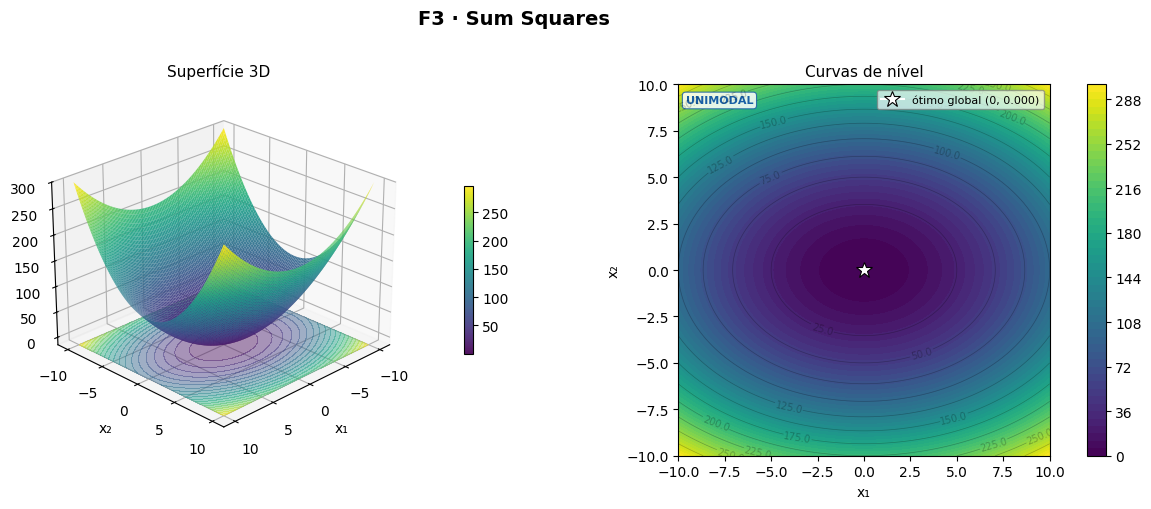

In [17]:
plot_function(sum_squares, (-10, 10), (-10, 10),
              title="F3 · Sum Squares", func_type="Unimodal",
              optimal_point=(0, 0))

### F4 · Dixon-Price
$$f(\mathbf{x}) = (x_1-1)^2 + \sum_{i=2}^{D} i\,(2x_i^2 - x_{i-1})^2 \qquad x_i \in [-10, 10], \quad f^* = 0$$
Não-separável; ótimo em $x_i^* = 2^{-(2^i-2)/2^i}$.

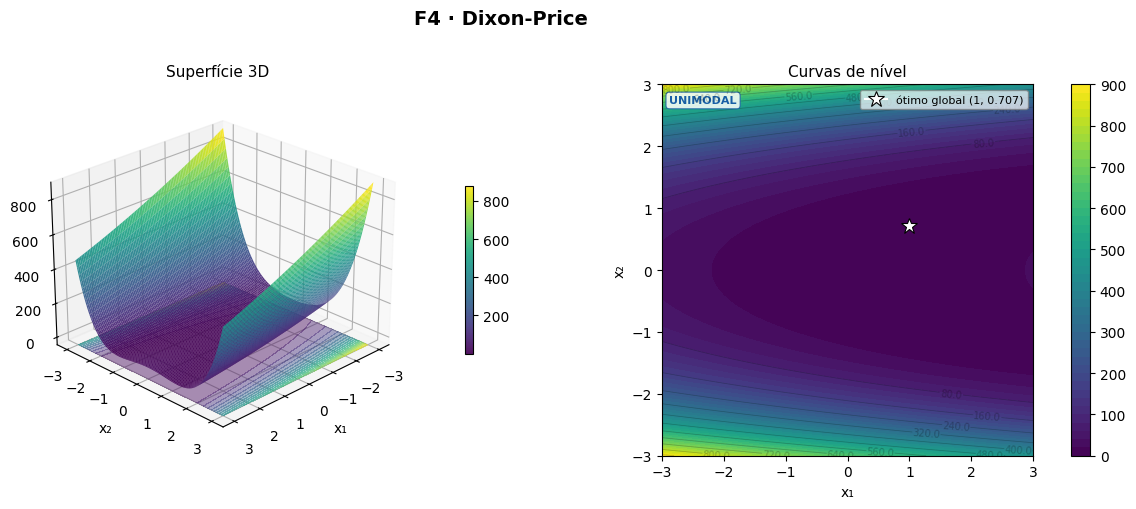

In [18]:
plot_function(dixon_price, (-3, 3), (-3, 3),
              title="F4 · Dixon-Price", func_type="Unimodal",
              optimal_point=(1, 1/np.sqrt(2)))

### F5 · Zakharov
$$f(\mathbf{x}) = \sum x_i^2 + \left(\sum 0.5i\,x_i\right)^2 + \left(\sum 0.5i\,x_i\right)^4 \qquad x_i \in [-5, 10], \quad f^* = 0$$
Não-separável; combina termos quadráticos e quárticos.

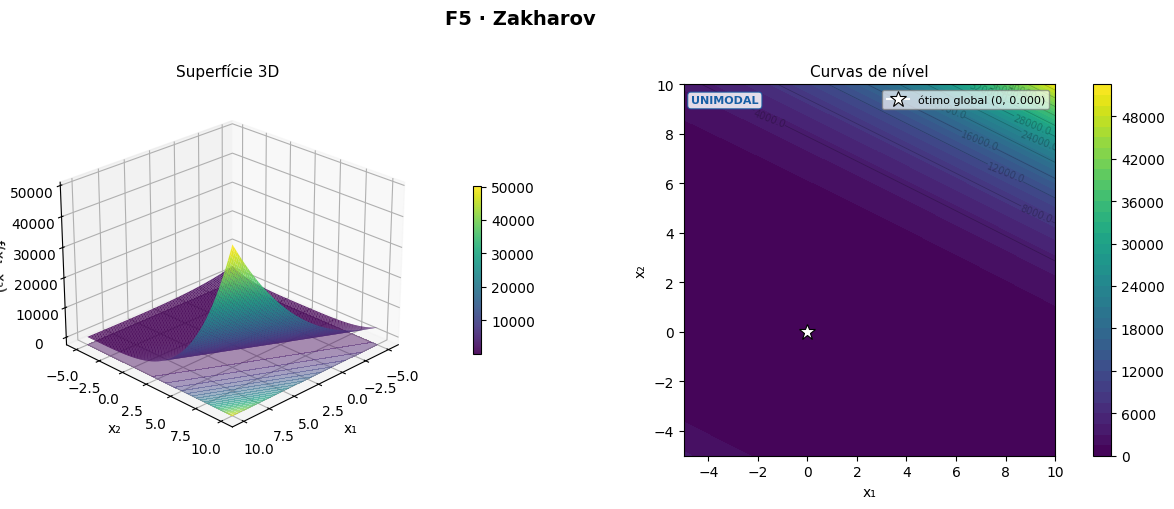

In [19]:
plot_function(zakharov, (-5, 10), (-5, 10),
              title="F5 · Zakharov", func_type="Unimodal",
              optimal_point=(0, 0))

## Funções Multimodais

Apresentam **múltiplos ótimos locais**. Testam a capacidade dos algoritmos de escapar de armadilhas e explorar o espaço de busca.

### F6 · Rastrigin
$$f(\mathbf{x}) = 10D + \sum_{i=1}^{D}\left[x_i^2 - 10\cos(2\pi x_i)\right] \qquad x_i \in [-5.12, 5.12], \quad f^* = 0$$
$\approx 10^D$ ótimos locais regularmente espaçados. Teste clássico de escape de armadilhas.

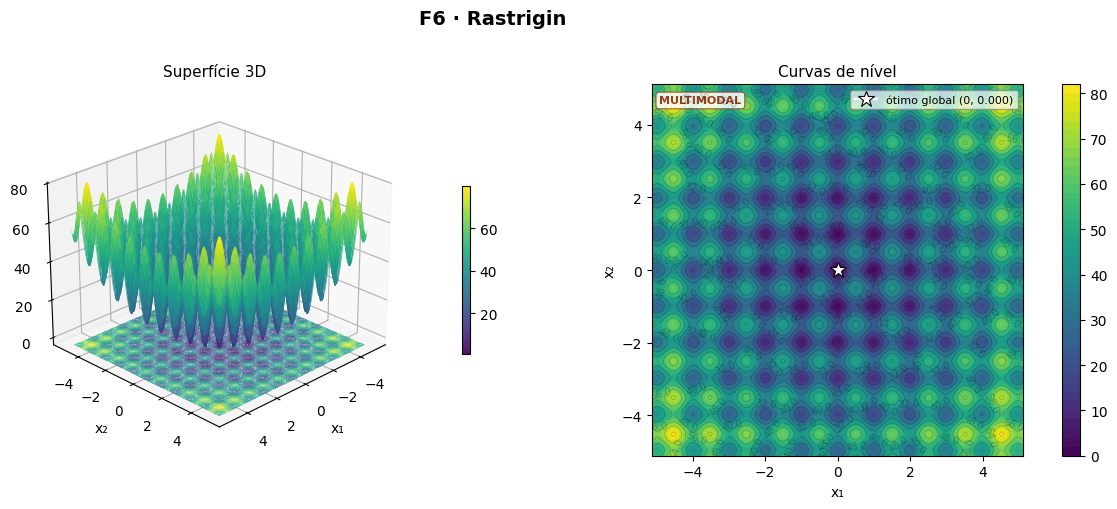

In [20]:
plot_function(rastrigin, (-5.12, 5.12), (-5.12, 5.12),
              title="F6 · Rastrigin", func_type="Multimodal",
              optimal_point=(0, 0))

### F7 · Ackley
$$f(\mathbf{x}) = -20\exp\!\left(-0.2\sqrt{\tfrac{1}{D}\sum x_i^2}\right) - \exp\!\left(\tfrac{1}{D}\sum\cos 2\pi x_i\right) + 20 + e$$
$x_i \in [-32.768, 32.768], \quad f^* = 0$

Exibida no domínio $[-5, 5]$ para revelar o platô externo e os picos locais ao redor da origem.

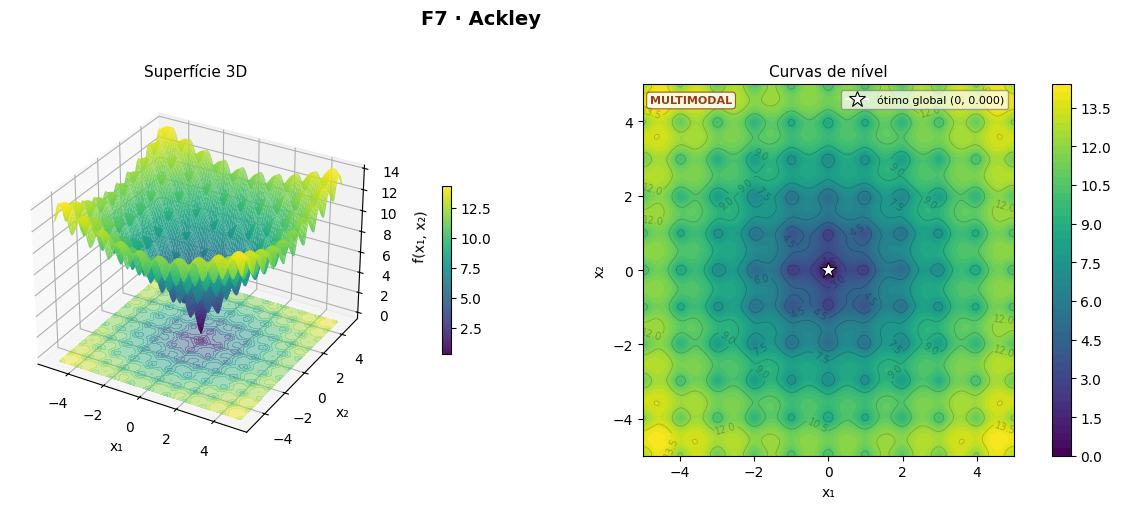

In [21]:
plot_function(
    ackley, (-5, 5), (-5, 5),         # [-5,5] revela melhor platô + ótimos locais
    title="F7 · Ackley", func_type="Multimodal",
    view_elev=30, view_azim=-60,
    optimal_point=(0, 0),
)

### F8 · Griewank
$$f(\mathbf{x}) = \frac{1}{4000}\sum x_i^2 - \prod\cos\!\left(\frac{x_i}{\sqrt{i}}\right) + 1 \qquad x_i \in [-600, 600], \quad f^* = 0$$

Exibida no domínio $[-10, 10]$: com $[-600, 600]$ a parábola domina completamente a escala
e as oscilações do produto cosseno — a característica multimodal da função — ficam invisíveis.

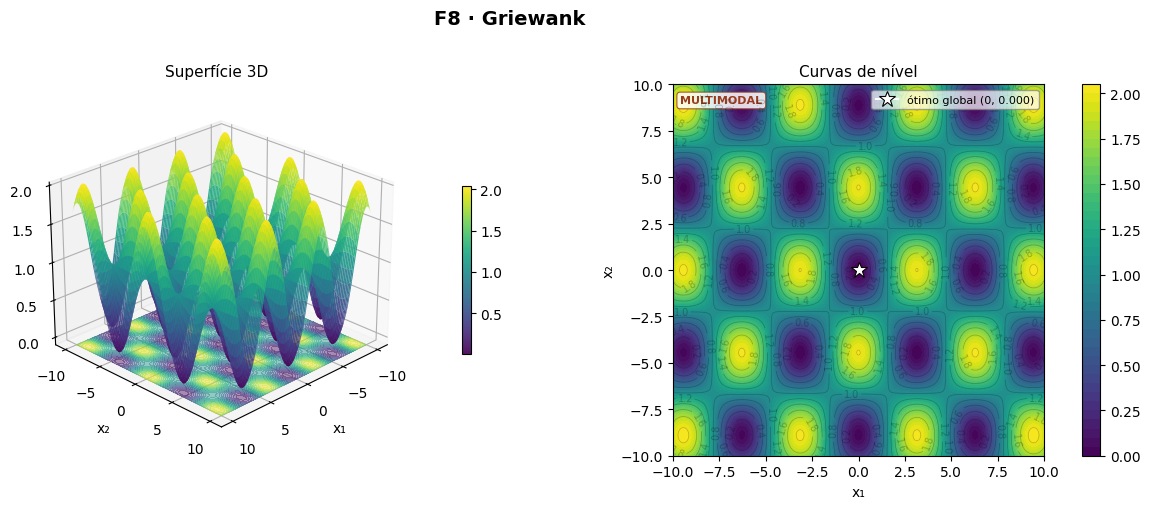

In [22]:
plot_function(
    griewank, (-10, 10), (-10, 10),   # [-10,10] revela as oscilações multimodais
    title="F8 · Griewank", func_type="Multimodal",
    optimal_point=(0, 0),
)

### F9 · Schwefel
$$f(\mathbf{x}) = 418.9829D - \sum_{i=1}^{D} x_i \sin\!\left(\sqrt{|x_i|}\right) \qquad x_i \in [-500, 500], \quad f^* = 0$$
Ótimo global em $x_i^* \approx 420.97$, longe do centro — engana algoritmos que convergem para $(0,0)$.

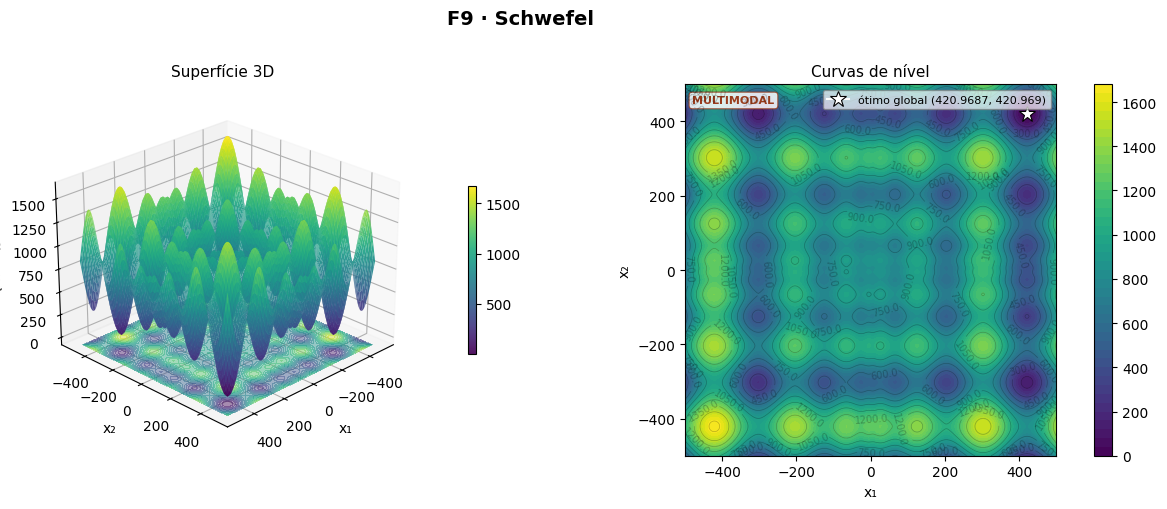

In [23]:
plot_function(schwefel, (-500, 500), (-500, 500),
              title="F9 · Schwefel", func_type="Multimodal",
              optimal_point=(420.9687, 420.9687))

### F10 · Levy
$$f(\mathbf{x}) = \sin^2(\pi w_1) + \sum_{i=1}^{D-1}(w_i-1)^2[1+10\sin^2(\pi w_{i+1})] + (w_D-1)^2[1+\sin^2(2\pi w_D)]$$
$w_i = 1 + (x_i-1)/4,\; x_i \in [-10,10], \quad f^* = 0$

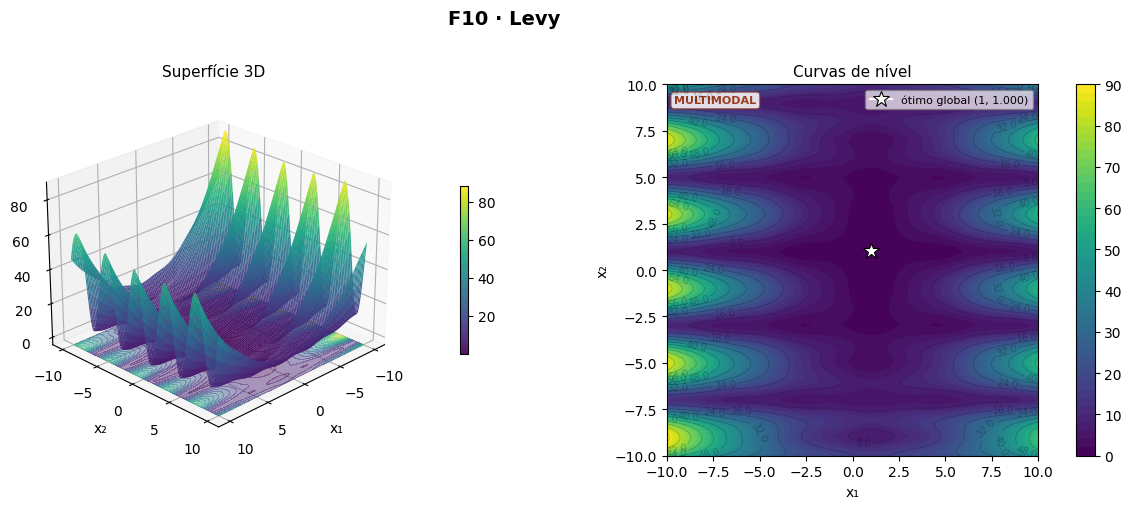

In [24]:
plot_function(levy, (-10, 10), (-10, 10),
              title="F10 · Levy", func_type="Multimodal",
              optimal_point=(1, 1))